<a href="https://colab.research.google.com/github/htutmyatoo/live-earthquake-monitor/blob/main/Myay_Gyi_AI_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔮 MYAY GYI AI — Aftershock Risk Predictor

[![Spotify](https://img.shields.io/badge/Dev%20Soundtrack-Kids%20(The%20Midnight)-1DB954?logo=spotify&logoColor=white)](https://open.spotify.com/track/5DDDOmwf5A73gx139EfoOU?si=ec769bf36364473f)
[![Streamlit](https://img.shields.io/badge/Streamlit-Open-FF4B4B)](https://myay-gyi-ai-v1.streamlit.app/)
![Machine Learning](https://img.shields.io/badge/Model-XGBoost-success)
![Explainability](https://img.shields.io/badge/Explainability-SHAP-purple)
[![Data Source](https://img.shields.io/badge/Data%20Source-USGS%20GeoJSON-orange)](https://earthquake.usgs.gov/)

This assessment notebook is to train an XGBoost binary classifier to predict the probability of a **M4.0+ aftershock occurring within 72 hours** of a triggering seismic event (M4.5+).

**Student Information:**
- Student Registration Number: 239638957
- Student Name: Htut Myat Oo
- Module: CETM46 A2

**Notebook Structure:**
1. Install & Import Libraries
2. Data Collection (USGS FDSN API, 2010–2025)
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Label Creation
5. Train/Test Split & Class Balancing
6. Model Training
7. Threshold Optimisation
8. Model Evaluation (ROC, Confusion Matrix, Metrics)
9. SHAP Explainability
10. Save Model Artifacts
11. Referenc

**Scientific Basis:**

Aftershock prediction uses Omori's Law: aftershock rate decays as `K / (t + c)^p` where `t` is time since main shock. Our ML approach learns this decay pattern alongside spatial and magnitude features from historical data.

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Shortcut Creation for Shared Folder

- Access the project folder via: https://drive.google.com/drive/folders/1_iX39nB6dOsNwtplpUPhdZ4gupRB9xA_?usp=sharing
- Right-click on the shared folder and select ``Add shortcut to Drive`` under ``Organize``.
- Choose "MyDrive/Colab Notebooks" as the location.

In [3]:
# This is the primary drive path for running on Colab.
path = "/content/drive/MyDrive/Colab Notebooks/MYAY GYI AI/"

## 1. Install & Import Libraries

In [ ]:
# Install required packages
!pip install xgboost shap imbalanced-learn -q

In [6]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import json
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from tqdm.notebook import tqdm

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score,
    cohen_kappa_score, log_loss, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
# from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette('husl')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully')
print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version:    {shap.__version__}')

Libraries loaded successfully
XGBoost version: 3.2.0
SHAP version:    0.51.0


## 2. Data Collection

We fetch historical earthquake data from the **USGS FDSN API** month-by-month (to stay within the 20,000 result limit per query).

- **Region:** Global, with a focus on the SE Asia / Myanmar bounding box
- **Period:** 2010–2025 (16 years of data)
- **Min magnitude:** M3.0 (we need events below our trigger threshold to label sequences)


In [7]:
def fetch_usgs_month(start_date: str, end_date: str,
                     min_mag: float = 3.0,
                     min_lat: float = None, max_lat: float = None,
                     min_lon: float = None, max_lon: float = None) -> pd.DataFrame:
    """
    Fetch earthquake data from USGS FDSN API for a single month.

    Parameters
    ----------
    start_date : str  — ISO format e.g. '2020-01-01'
    end_date   : str  — ISO format e.g. '2020-02-01'
    min_mag    : float — minimum magnitude to retrieve
    min_lat, max_lat, min_lon, max_lon : float — bounding box (optional)

    Returns
    -------
    pd.DataFrame with columns: time, latitude, longitude, depth, magnitude, place
    """
    base_url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format":       "csv",
        "starttime":    start_date,
        "endtime":      end_date,
        "minmagnitude": min_mag,
        "orderby":      "time-asc",
    }
    if min_lat is not None: params["minlatitude"]  = min_lat
    if max_lat is not None: params["maxlatitude"]  = max_lat
    if min_lon is not None: params["minlongitude"] = min_lon
    if max_lon is not None: params["maxlongitude"] = max_lon

    try:
        resp = requests.get(base_url, params=params, timeout=30)
        resp.raise_for_status()
        from io import StringIO
        df = pd.read_csv(StringIO(resp.text))
        df = df.rename(columns={'mag': 'magnitude'})
        df['time'] = pd.to_datetime(df['time'])
        df = df[['time', 'latitude', 'longitude', 'depth', 'magnitude', 'place']].dropna()
        return df
    except Exception as e:
        print(f'Error fetching {start_date}: {e}')
        return pd.DataFrame()


def fetch_usgs_range(start_year: int, end_year: int,
                     min_mag: float = 3.0,
                     bbox: dict = None) -> pd.DataFrame:
    """
    Fetch USGS data month-by-month across a year range.
    USGS caps results at 20,000 per query — monthly batches avoid this limit.

    Parameters
    ----------
    start_year : int
    end_year   : int (inclusive)
    min_mag    : float
    bbox       : dict with keys min_lat, max_lat, min_lon, max_lon (optional)

    Returns
    -------
    pd.DataFrame — combined dataset across all months
    """
    all_frames = []
    current = datetime(start_year, 1, 1)
    end     = datetime(end_year + 1, 1, 1)

    months = []
    while current < end:
        next_month = current + relativedelta(months=1)
        months.append((current.strftime('%Y-%m-%d'), next_month.strftime('%Y-%m-%d')))
        current = next_month

    for start_str, end_str in tqdm(months, desc='Fetching USGS data'):
        kwargs = {'min_mag': min_mag}
        if bbox:
            kwargs.update(bbox)
        df_month = fetch_usgs_month(start_str, end_str, **kwargs)
        if not df_month.empty:
            all_frames.append(df_month)

    if not all_frames:
        raise ValueError('No data fetched — check your parameters and internet connection.')

    combined = pd.concat(all_frames, ignore_index=True)
    combined = combined.sort_values('time').reset_index(drop=True)
    combined = combined.drop_duplicates(subset=['time', 'latitude', 'longitude'])
    return combined

print('Fetch functions defined')

Fetch functions defined


In [8]:
# ─────────────────────────────────────────────────────────────────
# Myanmar + SE Asia region
# Bounding box covers Myanmar, Thailand, Laos, parts of China & India
# ─────────────────────────────────────────────────────────────────
MYANMAR_BBOX = {
    'min_lat': 5.0,  'max_lat': 35.0,
    'min_lon': 85.0, 'max_lon': 110.0
}

print('📡 Fetching Myanmar/SE Asia earthquake data (2010–2025)...')
df_raw = fetch_usgs_range(
    start_year=2010,
    end_year=2025,
    min_mag=3.0,
    bbox=MYANMAR_BBOX
)

print(f'\nFetched {len(df_raw):,} earthquake records')
print(f'   Date range: {df_raw["time"].min().date()} → {df_raw["time"].max().date()}')
print(f'   Magnitude range: M{df_raw["magnitude"].min():.1f} → M{df_raw["magnitude"].max():.1f}')
df_raw.head()

📡 Fetching Myanmar/SE Asia earthquake data (2010–2025)...


Fetching USGS data:   0%|          | 0/192 [00:00<?, ?it/s]


Fetched 5,973 earthquake records
   Date range: 2010-01-01 → 2025-12-31
   Magnitude range: M3.1 → M7.7


,time,latitude,longitude,depth,magnitude,place
0,2010-01-01 02:08:21.900000+00:00,26.290,99.866,10.0,5.0,"73 km SSW of Lijiang, China"
1,2010-01-05 14:28:18.340000+00:00,32.384,85.273,54.1,4.9,western Xizang
2,2010-01-07 12:44:06.270000+00:00,26.013,105.305,10.0,4.0,"68 km WSW of Anshun, China"
3,2010-01-11 03:38:43.300000+00:00,14.243,93.505,66.4,4.0,"294 km NNE of Bamboo Flat, India"
4,2010-01-16 06:31:29.530000+00:00,14.161,93.145,44.2,4.9,"276 km N of Bamboo Flat, India"


In [9]:
# ─────────────────────────────────────────────────────────────────
# Add global data for stronger model generalisation
# ─────────────────────────────────────────────────────────────────
print('📡 Fetching GLOBAL earthquake data (2010–2025)...')
df_global = fetch_usgs_range(start_year=2010, end_year=2025, min_mag=3.5)
print(f'Fetched {len(df_global):,} global records')
# Combine with Myanmar data:
df_raw = pd.concat([df_raw, df_global]).drop_duplicates(
    subset=['time','latitude','longitude']).sort_values('time').reset_index(drop=True)
print(f'Combined: {len(df_raw):,} records')

# Save raw data checkpoint
os.makedirs(path + 'data', exist_ok=True)
df_raw.to_csv(path + 'data/raw_earthquakes.csv', index=False)
print('Raw data saved to data/raw_earthquakes.csv')

📡 Fetching GLOBAL earthquake data (2010–2025)...


Fetching USGS data:   0%|          | 0/192 [00:00<?, ?it/s]

Fetched 259,306 global records
Combined: 259,314 records
Raw data saved to data/raw_earthquakes.csv


In [10]:
# ----------------------------------------------------------
# Build Fault Reference Dataset (Centroid Approximation)
# ----------------------------------------------------------
FAULTS = [
    {"fault_name":"Sagaing Fault", "lat":21.5, "lon":96.0, "type":"Strike-slip"},
    {"fault_name":"Shan Scarp Fault", "lat":21.0, "lon":98.5, "type":"Thrust"},
    {"fault_name":"Kyaukkyan Fault", "lat":24.5, "lon":97.5, "type":"Strike-slip"},
    {"fault_name":"Dawei Fault", "lat":14.5, "lon":98.5, "type":"Thrust"},
    {"fault_name":"Three Pagodas Fault", "lat":15.5, "lon":99.0, "type":"Strike-slip"},
    {"fault_name":"San Andreas Fault", "lat":36.0, "lon":-120.5, "type":"Strike-slip"},
    {"fault_name":"North Anatolian Fault", "lat":40.8, "lon":33.0, "type":"Strike-slip"},
    {"fault_name":"Japan Trench", "lat":38.0, "lon":143.5, "type":"Subduction"},
    {"fault_name":"Sumatra-Andaman Zone", "lat":4.0, "lon":95.0, "type":"Subduction"},
    {"fault_name":"Cascadia Zone", "lat":45.5, "lon":-124.0, "type":"Subduction"},
]

df_faults = pd.DataFrame(FAULTS)

# ----------------------------------------------------------
# Haversine Distance Function
# ----------------------------------------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# ----------------------------------------------------------
# Find Nearest Fault for Each Earthquake
# ----------------------------------------------------------
def nearest_fault_features(eq_lat, eq_lon):
    distances = df_faults.apply(
        lambda row: haversine_km(eq_lat, eq_lon, row["lat"], row["lon"]),
        axis=1
    )

    idx = distances.idxmin()

    return pd.Series({
        "nearest_fault": df_faults.loc[idx, "fault_name"],
        "nearest_fault_type": df_faults.loc[idx, "type"],
        "nearest_fault_km": round(distances.min(), 2),
        "is_near_fault": int(distances.min() <= 100)
    })

# ----------------------------------------------------------
# Apply to Earthquake Dataset
# ----------------------------------------------------------
fault_features = df_raw.apply(
    lambda row: nearest_fault_features(row["latitude"], row["longitude"]),
    axis=1
)

df_raw = pd.concat([df_raw, fault_features], axis=1)

# ----------------------------------------------------------
# Preview
# ----------------------------------------------------------
print("Fault enrichment complete.")
print(df_raw[
    ["place","latitude","longitude","nearest_fault",
     "nearest_fault_type","nearest_fault_km","is_near_fault"]
].head())

Fault enrichment complete.
                                    place  latitude  longitude  \
0             73 km SSW of Lijiang, China    26.290     99.866   
1                201 km NW of Saga, China    30.646     83.791   
2  117 km NW of Türkmenba?y, Turkmenistan    40.726     51.925   
3   180 km SE of Pondaguitan, Philippines     5.027    127.121   
4  125 km NNE of Cabodiongan, Philippines    13.687    125.554   

           nearest_fault nearest_fault_type  nearest_fault_km  is_near_fault  
0        Kyaukkyan Fault        Strike-slip            309.99              0  
1        Kyaukkyan Fault        Strike-slip           1512.55              0  
2  North Anatolian Fault        Strike-slip           1590.80              0  
3    Three Pagodas Fault        Strike-slip           3284.52              0  
4    Three Pagodas Fault        Strike-slip           2862.72              0  



## 3. Exploratory Data Analysis (EDA)

In [11]:
print('=== DATASET OVERVIEW ===')
print(f'Shape:   {df_raw.shape}')
print(f'Nulls:\n{df_raw.isnull().sum()}')
print(f'\nDtypes:\n{df_raw.dtypes}')
df_raw.describe()

=== DATASET OVERVIEW ===
Shape:   (259314, 10)
Nulls:
time                  0
latitude              0
longitude             0
depth                 0
magnitude             0
place                 0
nearest_fault         0
nearest_fault_type    0
nearest_fault_km      0
is_near_fault         0
dtype: int64

Dtypes:
time                  datetime64[ns, UTC]
latitude                          float64
longitude                         float64
depth                             float64
magnitude                         float64
place                              object
nearest_fault                      object
nearest_fault_type                 object
nearest_fault_km                  float64
is_near_fault                       int64
dtype: object


,latitude,longitude,depth,magnitude,nearest_fault_km,is_near_fault
count,259314.000000,259314.000000,259314.000000,259314.000000,259314.000000,259314.000000
mean,6.104401,27.114515,77.097468,4.466089,4526.832568,0.007111
std,30.703067,124.909249,127.831039,0.447052,3062.085386,0.084027
min,-84.422000,-179.999700,-3.740000,3.100000,2.500000,0.000000
25%,-17.980800,-79.928450,10.000000,4.200000,2172.802500,0.000000
50%,3.314100,73.514550,30.000000,4.400000,3687.415000,0.000000
75%,33.767500,141.577925,76.060000,4.700000,7342.025000,0.000000
max,87.386000,179.999400,697.360000,9.100000,12810.950000,1.000000


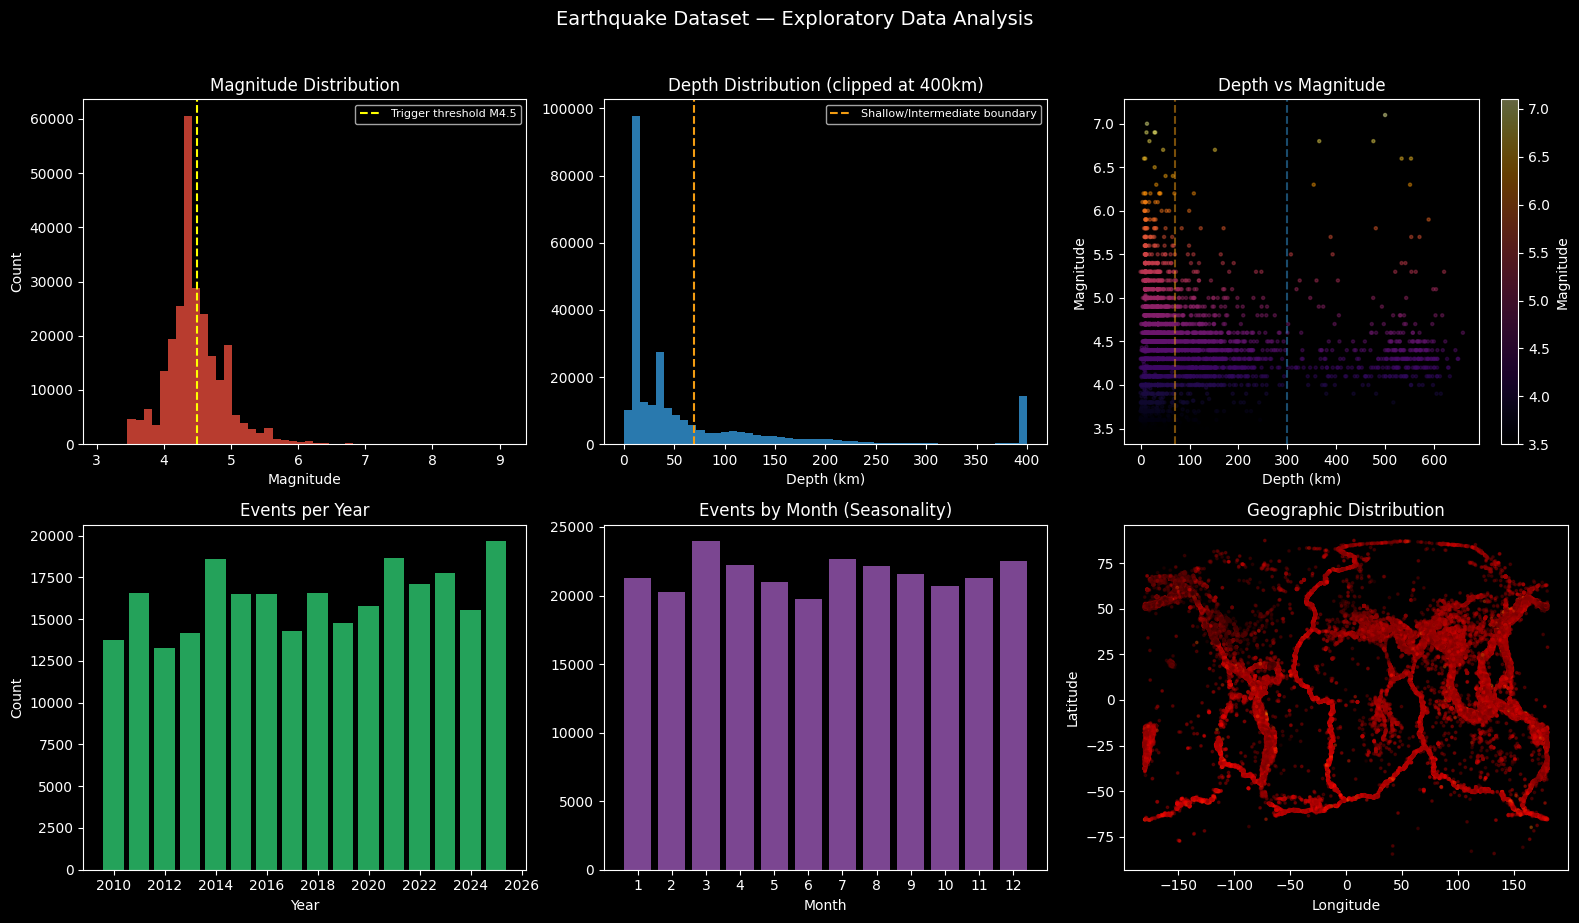

EDA plots saved to data/eda_plots.png


In [12]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Earthquake Dataset — Exploratory Data Analysis', fontsize=14, y=1.02)

# 1. Magnitude distribution
axes[0,0].hist(df_raw['magnitude'], bins=50, color='#e74c3c', alpha=0.8, edgecolor='none')
axes[0,0].set_title('Magnitude Distribution')
axes[0,0].set_xlabel('Magnitude')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(4.5, color='yellow', linestyle='--', label='Trigger threshold M4.5')
axes[0,0].legend(fontsize=8)

# 2. Depth distribution
axes[0,1].hist(df_raw['depth'].clip(0, 400), bins=50, color='#3498db', alpha=0.8, edgecolor='none')
axes[0,1].set_title('Depth Distribution (clipped at 400km)')
axes[0,1].set_xlabel('Depth (km)')
axes[0,1].axvline(70, color='#f39c12', linestyle='--', label='Shallow/Intermediate boundary')
axes[0,1].legend(fontsize=8)

# 3. Depth vs Magnitude scatter
sample = df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_STATE)
scatter = axes[0,2].scatter(
    sample['depth'], sample['magnitude'],
    c=sample['magnitude'], cmap='inferno', alpha=0.4, s=5
)
plt.colorbar(scatter, ax=axes[0,2], label='Magnitude')
axes[0,2].set_title('Depth vs Magnitude')
axes[0,2].set_xlabel('Depth (km)')
axes[0,2].set_ylabel('Magnitude')
axes[0,2].axvline(70,  color='#f39c12', linestyle='--', alpha=0.5)
axes[0,2].axvline(300, color='#3498db', linestyle='--', alpha=0.5)

# 4. Events per year
yearly = df_raw.groupby(df_raw['time'].dt.year).size()
axes[1,0].bar(yearly.index, yearly.values, color='#2ecc71', alpha=0.8)
axes[1,0].set_title('Events per Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Count')

# 5. Events by month (seasonality)
monthly = df_raw.groupby(df_raw['time'].dt.month).size()
axes[1,1].bar(monthly.index, monthly.values, color='#9b59b6', alpha=0.8)
axes[1,1].set_title('Events by Month (Seasonality)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_xticks(range(1,13))

# 6. Geographic distribution
axes[1,2].scatter(
    df_raw['longitude'], df_raw['latitude'],
    c=df_raw['magnitude'], cmap='hot', alpha=0.3, s=3
)
axes[1,2].set_title('Geographic Distribution')
axes[1,2].set_xlabel('Longitude')
axes[1,2].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(path + 'data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved to data/eda_plots.png')

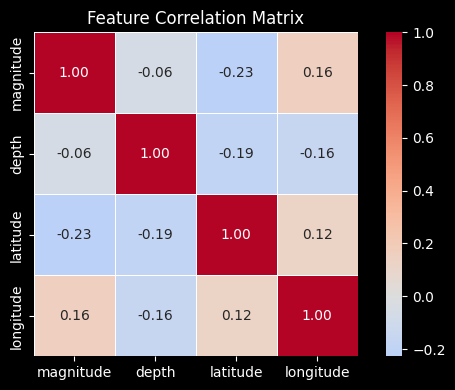

In [13]:
# Correlation heatmap of numeric features
plt.figure(figsize=(6, 4))
corr = df_raw[['magnitude', 'depth', 'latitude', 'longitude']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(path + 'data/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Label Creation

### Label Definition
For each **triggering event** (M≥4.5), look within a **100 km radius** and **72-hour window** for any subsequent M≥4.0 earthquake. If one exists → **label = 1** (aftershock occurred). Otherwise → **label = 0**.

### Features
| Feature | Description | Seismological basis |
|---|---|---|
| `magnitude` | Main shock magnitude | Larger quakes produce more aftershocks (Gutenberg-Richter) |
| `depth` | Hypocentre depth (km) | Shallow quakes have higher aftershock rates |
| `depth_category` | 0=shallow, 1=intermediate, 2=deep | Categorical depth encoding |
| `seismicity_rate_30d` | M3+ events in 30 days within 200 km | Background seismicity proxy |
| `seismicity_rate_7d` | M3+ events in 7 days within 200 km | Short-term seismicity proxy |
| `hour_of_day` | Hour of triggering event | Minor diurnal pattern |
| `month` | Month of triggering event | Seasonal seismicity patterns |
| `is_myanmar_region` | 1 if within Myanmar bounding box | Region-specific fault behaviour |
| `lat_bin` | Latitude binned to 5° cells | Spatial seismicity zone proxy |
| `lon_bin` | Longitude binned to 5° cells | Spatial seismicity zone proxy |


In [14]:
def haversine_distance(lat1: float, lon1: float,
                       lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """
    Vectorised Haversine formula — great-circle distance in kilometres.
    Used to find earthquakes within a radius of a trigger event.
    """
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))


def compute_seismicity_rate(trigger_time: pd.Timestamp,
                             trigger_lat: float, trigger_lon: float,
                             df: pd.DataFrame,
                             days_back: int, radius_km: float,
                             min_mag: float = 3.0) -> int:
    """
    Count M≥min_mag earthquakes within radius_km and days_back days
    BEFORE the trigger event. Measures background seismicity.
    """
    window_start = trigger_time - pd.Timedelta(days=days_back)
    candidates = df[
        (df['time'] >= window_start) &
        (df['time'] < trigger_time) &
        (df['magnitude'] >= min_mag)
    ]
    if candidates.empty:
        return 0
    dists = haversine_distance(
        trigger_lat, trigger_lon,
        candidates['latitude'].values, candidates['longitude'].values
    )
    return int((dists <= radius_km).sum())


def has_aftershock(trigger_time: pd.Timestamp,
                   trigger_lat: float, trigger_lon: float,
                   df: pd.DataFrame,
                   hours: int = 72, radius_km: float = 100.0,
                   min_aftershock_mag: float = 4.0) -> int:
    """
    Binary label: 1 if a M≥min_aftershock_mag earthquake occurred
    within radius_km and hours after the trigger event, else 0.
    """
    window_end = trigger_time + pd.Timedelta(hours=hours)
    candidates = df[
        (df['time'] > trigger_time) &
        (df['time'] <= window_end) &
        (df['magnitude'] >= min_aftershock_mag)
    ]
    if candidates.empty:
        return 0
    dists = haversine_distance(
        trigger_lat, trigger_lon,
        candidates['latitude'].values, candidates['longitude'].values
    )
    return int((dists <= radius_km).any())


print('Feature engineering functions defined')

Feature engineering functions defined


In [15]:
# ── Build the labelled dataset ──────────────────────────────────────
# Trigger events: M≥4.5 (significant enough to be "main shocks")
TRIGGER_MIN_MAG    = 4.5
AFTERSHOCK_MIN_MAG = 4.0
AFTERSHOCK_HOURS   = 72
AFTERSHOCK_RADIUS  = 100   # km
SEISMICITY_RADIUS  = 200   # km for background rate

triggers = df_raw[df_raw['magnitude'] >= TRIGGER_MIN_MAG].copy().reset_index(drop=True)
print(f'Trigger events (M≥{TRIGGER_MIN_MAG}): {len(triggers):,}')
print(f'Labelling {len(triggers):,} events — this may take a few minutes...\n')

records = []
for _, row in tqdm(triggers.iterrows(), total=len(triggers), desc='Building features'):
    t    = row['time']
    lat  = row['latitude']
    lon  = row['longitude']
    mag  = row['magnitude']
    dep  = row['depth']
    fault_km = row['nearest_fault_km']
    near_fault = row['is_near_fault']

    # Background seismicity (before trigger, not including trigger itself)
    rate_30d = compute_seismicity_rate(t, lat, lon, df_raw, 30, SEISMICITY_RADIUS)
    rate_7d  = compute_seismicity_rate(t, lat, lon, df_raw, 7,  SEISMICITY_RADIUS)

    # Depth category (seismological classification)
    if dep < 70:    depth_cat = 0  # shallow
    elif dep < 300: depth_cat = 1  # intermediate
    else:           depth_cat = 2  # deep

    # Binary label
    label = has_aftershock(t, lat, lon, df_raw,
                            AFTERSHOCK_HOURS, AFTERSHOCK_RADIUS, AFTERSHOCK_MIN_MAG)

    records.append({
        'magnitude':          mag,
        'depth':              dep,
        'depth_category':     depth_cat,
        'seismicity_rate_30d': rate_30d,
        'seismicity_rate_7d':  rate_7d,
        'hour_of_day':        t.hour,
        'month':              t.month,
        'latitude':           lat,
        'longitude':          lon,
        'lat_bin':            round(lat / 5) * 5,
        'lon_bin':            round(lon / 5) * 5,
        'is_myanmar_region':  int(5 <= lat <= 35 and 85 <= lon <= 110),
        'nearest_fault_km':   fault_km,
        'is_near_fault':      near_fault,
        'fault_pressure':     mag / (fault_km + 1),
        'label':              label,
        'time':               t,
        'place':              row['place'],
    })

df_labelled = pd.DataFrame(records)
print(f'\nLabelled dataset built: {len(df_labelled):,} rows')
print(f'\nClass distribution:')
print(df_labelled['label'].value_counts())
print(f'Aftershock rate: {df_labelled["label"].mean()*100:.1f}%')

df_labelled.to_csv(path + 'data/labelled_dataset.csv', index=False)
print('\nSaved to data/labelled_dataset.csv')

Trigger events (M≥4.5): 121,119
Labelling 121,119 events — this may take a few minutes...



Building features:   0%|          | 0/121119 [00:00<?, ?it/s]


Labelled dataset built: 121,119 rows

Class distribution:
label
0    62160
1    58959
Name: count, dtype: int64
Aftershock rate: 48.7%

Saved to data/labelled_dataset.csv


In [16]:
# Run this to load built labelled dataset
# df_labelled = pd.read_csv(
#     path + 'data/labelled_dataset.csv',
#     parse_dates=['time']
# )

# print(df_labelled.shape)
# df_labelled.head()

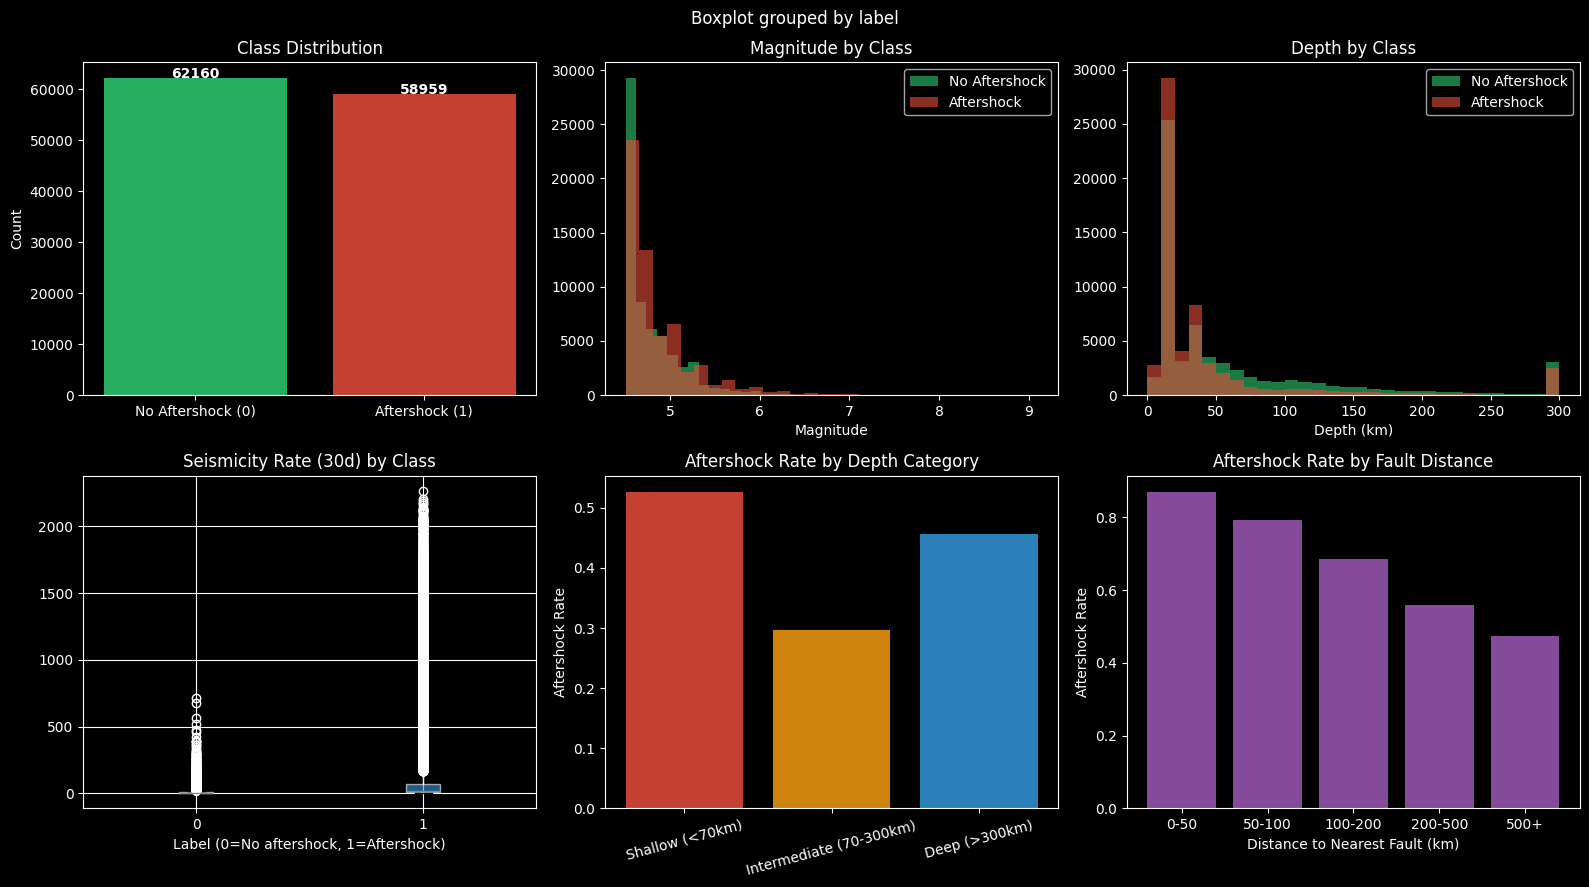

In [17]:
# Visualise class balance and key feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Engineering — Labelled Dataset', fontsize=14)

# Class balance
counts = df_labelled['label'].value_counts()
axes[0,0].bar(['No Aftershock (0)', 'Aftershock (1)'], counts.values,
               color=['#2ecc71', '#e74c3c'], alpha=0.85)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Magnitude by class
for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
    axes[0,1].hist(df_labelled[df_labelled['label']==label]['magnitude'],
                   bins=30, alpha=0.6, color=color,
                   label=f'{"Aftershock" if label else "No Aftershock"}')
axes[0,1].set_title('Magnitude by Class')
axes[0,1].set_xlabel('Magnitude')
axes[0,1].legend()

# Depth by class
for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
    axes[0,2].hist(df_labelled[df_labelled['label']==label]['depth'].clip(0, 300),
                   bins=30, alpha=0.6, color=color,
                   label=f'{"Aftershock" if label else "No Aftershock"}')
axes[0,2].set_title('Depth by Class')
axes[0,2].set_xlabel('Depth (km)')
axes[0,2].legend()

# Seismicity rate 30d by class
df_labelled.boxplot(column='seismicity_rate_30d', by='label', ax=axes[1,0],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1,0].set_title('Seismicity Rate (30d) by Class')
axes[1,0].set_xlabel('Label (0=No aftershock, 1=Aftershock)')

# Aftershock rate by depth category
depth_labels = ['Shallow (<70km)', 'Intermediate (70-300km)', 'Deep (>300km)']
depth_rates  = [df_labelled[df_labelled['depth_category']==i]['label'].mean()
                for i in range(3)]
axes[1,1].bar(depth_labels, depth_rates, color=['#e74c3c','#f39c12','#3498db'], alpha=0.85)
axes[1,1].set_title('Aftershock Rate by Depth Category')
axes[1,1].set_ylabel('Aftershock Rate')
axes[1,1].tick_params(axis='x', rotation=15)

# Aftershock rate by magnitude band
# df_labelled['mag_band'] = pd.cut(df_labelled['magnitude'],
#                                    bins=[4.5, 5.0, 5.5, 6.0, 6.5, 10.0],
#                                    labels=['4.5-5.0','5.0-5.5','5.5-6.0','6.0-6.5','6.5+'])
# mag_rates = df_labelled.groupby('mag_band')['label'].mean()
# axes[1,2].bar(mag_rates.index.astype(str), mag_rates.values, color='#e74c3c', alpha=0.85)
# axes[1,2].set_title('Aftershock Rate by Magnitude Band')
# axes[1,2].set_ylabel('Aftershock Rate')
# axes[1,2].set_xlabel('Magnitude Band')

# Aftershock Rate by Fault Proximity
df_labelled["fault_band"] = pd.cut(
    df_labelled["nearest_fault_km"],
    bins=[0,50,100,200,500,99999],
    labels=["0-50","50-100","100-200","200-500","500+"]
)

fault_rates = df_labelled.groupby("fault_band")["label"].mean()

axes[1,2].bar(
    fault_rates.index.astype(str),
    fault_rates.values,
    color="#9b59b6",
    alpha=0.85
)

axes[1,2].set_title("Aftershock Rate by Fault Distance")
axes[1,2].set_ylabel("Aftershock Rate")
axes[1,2].set_xlabel("Distance to Nearest Fault (km)")

plt.tight_layout()
plt.savefig(path + 'data/feature_engineering_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train/Test Split & Class Balancing

In [18]:
# Feature columns used for training
FEATURE_COLS = [
    'magnitude',
    'depth',
    'depth_category',
    'seismicity_rate_30d',
    'seismicity_rate_7d',
    'hour_of_day',
    'month',
    'lat_bin',
    'lon_bin',
    'is_myanmar_region',
    'nearest_fault_km',
    'is_near_fault',
    'fault_pressure',
]

X = df_labelled[FEATURE_COLS].copy()
y = df_labelled['label'].copy()

print(f'Features: {FEATURE_COLS}')
print(f'X shape:  {X.shape}')
print(f'y shape:  {y.shape}')
print(f'Class balance: {y.value_counts().to_dict()}')

# Temporal split — use last 2 years as test set
# This prevents data leakage (future events cannot inform past predictions)
cutoff_date = df_labelled['time'].max() - pd.Timedelta(days=365*2)
train_mask  = df_labelled['time'] < cutoff_date
test_mask   = df_labelled['time'] >= cutoff_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'\nTemporal split (last 2 years as test):')
print(f'  Train: {len(X_train):,} samples | Test: {len(X_test):,} samples')
print(f'  Train aftershock rate: {y_train.mean()*100:.1f}%')
print(f'  Test  aftershock rate: {y_test.mean()*100:.1f}%')

Features: ['magnitude', 'depth', 'depth_category', 'seismicity_rate_30d', 'seismicity_rate_7d', 'hour_of_day', 'month', 'lat_bin', 'lon_bin', 'is_myanmar_region', 'nearest_fault_km', 'is_near_fault', 'fault_pressure']
X shape:  (121119, 13)
y shape:  (121119,)
Class balance: {0: 62160, 1: 58959}

Temporal split (last 2 years as test):
  Train: 106,212 samples | Test: 14,907 samples
  Train aftershock rate: 48.5%
  Test  aftershock rate: 49.9%


Note: **Although SMOTE was experimentally evaluated to address potential imbalance, the labelled dataset was already near-balanced. Models trained on original observations consistently outperformed oversampled variants, so the final pipeline retained real seismic records only.**

In [19]:
# Class balancing with SMOTE (Synthetic Minority Over-sampling Technique)
# print('Applying SMOTE to training data...')
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
# print(f'After  SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}')

# # Visualise class balance before/after
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# before = y_train.value_counts()
# ax1.bar(['No Aftershock', 'Aftershock'], before.values, color=['#2ecc71','#e74c3c'], alpha=0.85)
# ax1.set_title('Before SMOTE')
# ax1.set_ylabel('Count')

# after = pd.Series(y_train_bal).value_counts()
# ax2.bar(['No Aftershock', 'Aftershock'], after.values, color=['#2ecc71','#e74c3c'], alpha=0.85)
# ax2.set_title('After SMOTE')

# plt.suptitle('Class Balancing with SMOTE')
# plt.tight_layout()
# plt.savefig('data/smote_balance.png', dpi=150, bbox_inches='tight')
# plt.show()

Using original training data (SMOTE removed).
Training class balance: {0: 54698, 1: 51514}


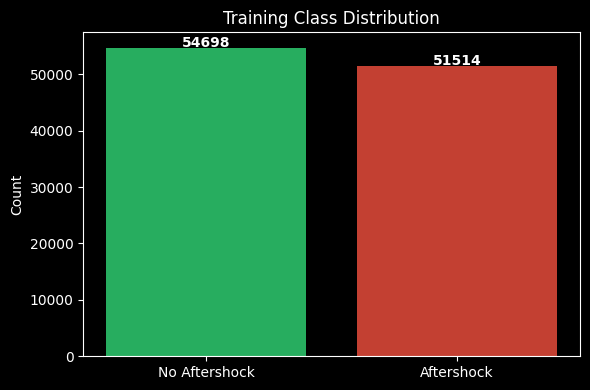

In [20]:
print("Using original training data (SMOTE removed).")

X_train_bal = X_train.copy()
y_train_bal = y_train.copy()

print(f"Training class balance: {y_train_bal.value_counts().to_dict()}")

# Visualise class distribution
fig, ax = plt.subplots(figsize=(6,4))

counts = y_train_bal.value_counts()

ax.bar(
    ['No Aftershock', 'Aftershock'],
    counts.values,
    color=['#2ecc71', '#e74c3c'],
    alpha=0.85
)

ax.set_title("Training Class Distribution")
ax.set_ylabel("Count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(path + "data/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Model Training

In [21]:
# ==========================================================
# Model Benchmarking & Final XGBoost Training
# Compares:
#   - Baseline Dummy Classifier
#   - Logistic Regression
#   - Random Forest
#   - XGBoost
# ==========================================================

results = []

# ----------------------------------------------------------
# Helper function
# ----------------------------------------------------------
def evaluate_model(name, model, use_proba=True):
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)

    if use_proba and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(row)

    # print(f"\n=== {name.upper()} ===")
    # for k, v in row.items():
    #     if k != "Model":
    #         print(f"{k:<10}: {v:.4f}")

    return model

# ----------------------------------------------------------
# Baseline Model
# ----------------------------------------------------------
baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

evaluate_model("Baseline", baseline, use_proba=False)


# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

evaluate_model("Logistic Regression", lr)

# ----------------------------------------------------------
# Random Forest
# ----------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model("Random Forest", rf)

# ----------------------------------------------------------
# XGBoost Model
# ----------------------------------------------------------
neg_count = (y_train_bal == 0).sum()
pos_count = (y_train_bal == 1).sum()
scale_pos = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    verbosity=0
)

evaluate_model("XGBoost", xgb_model)

# ----------------------------------------------------------
# Final Leaderboard
# ----------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("AUC", ascending=False)

print("\n=== MODEL COMPARISON ===")
display(results_df.round(4))


=== MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1,AUC
3,XGBoost,0.7605,0.8071,0.6839,0.7404,0.8432
2,Random Forest,0.7605,0.8306,0.6539,0.7317,0.8402
1,Logistic Regression,0.7399,0.8741,0.5597,0.6824,0.8069
0,Baseline,0.5006,0.0000,0.0000,0.0000,0.5000


In [22]:
# ----------------------------------------------------------
# Cross-validation on Final XGBoost Model
# ----------------------------------------------------------
print("\nRunning 5-fold cross-validation on XGBoost...")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    verbosity=0
)

cv_scores = cross_val_score(
    cv_model,
    X_train_bal,
    y_train_bal,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print(f"CV AUC Scores: {[round(s,4) for s in cv_scores]}")
print(f"Mean AUC     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ----------------------------------------------------------
# Final Deployment Model Reference
# ----------------------------------------------------------
model = xgb_model
print("\n=== FINAL MODEL REFERENCE ===")
display(model)


Running 5-fold cross-validation on XGBoost...
CV AUC Scores: [np.float64(0.8499), np.float64(0.8415), np.float64(0.8427), np.float64(0.8457), np.float64(0.8431)]
Mean AUC     : 0.8446 ± 0.0030

=== FINAL MODEL REFERENCE ===


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## 7. Threshold Optimisation (XGBoost)

Note: **Hyperparameter optimisation was conducted, however, gains were marginal and did not surpass the manually selected baseline configuration. Therefore, the original tuned-by-design XGBoost model was retained.**

In [23]:
# ==========================================================
# 7 ─ Threshold Optimisation
# Find best classification threshold for aftershock detection
# ==========================================================

# Prediction probabilities
y_pred_prob = model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.30, 0.71, 0.02)

rows = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)

    rows.append({
        "Threshold": round(t,2),
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1 Score": f1_score(y_test, y_pred_t)
    })

threshold_results = pd.DataFrame(rows)
threshold_results = threshold_results.sort_values("F1 Score", ascending=False)

print("=== TOP THRESHOLDS ===")
display(threshold_results.head(10))

=== TOP THRESHOLDS ===


,Threshold,Precision,Recall,F1 Score
6,0.42,0.744086,0.768972,0.756325
7,0.44,0.761833,0.750168,0.755956
5,0.40,0.726697,0.786434,0.755386
4,0.38,0.710495,0.805641,0.755083
3,0.36,0.695889,0.823103,0.754169
2,0.34,0.682571,0.841639,0.753805
1,0.32,0.667223,0.859637,0.751306
8,0.46,0.776122,0.727334,0.750936
0,0.30,0.653946,0.876964,0.749211
9,0.48,0.790536,0.704634,0.745118


In [24]:
best_threshold = threshold_results.iloc[0]["Threshold"]
print("Selected Threshold:", best_threshold)

Selected Threshold: 0.42


## 8. Model Evaluation

In [25]:
# Predictions
# y_pred      = model.predict(X_test)
# y_pred_prob = model.predict_proba(X_test)[:, 1]

y_pred_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Metrics
metrics = {
    'Accuracy':     accuracy_score(y_test, y_pred),
    'Precision':    precision_score(y_test, y_pred),
    'Recall':       recall_score(y_test, y_pred),
    'F1 Score':     f1_score(y_test, y_pred),
    'AUC-ROC':      roc_auc_score(y_test, y_pred_prob),
    'Cohen Kappa':  cohen_kappa_score(y_test, y_pred),
    'Log Loss':     log_loss(y_test, y_pred_prob),
}

print('=== MODEL PERFORMANCE METRICS ===')
for name, val in metrics.items():
    print(f'  {name:<15} {val:.4f}')

print(f'\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred,
                             target_names=['No Aftershock', 'Aftershock']))

# Save metrics for the Streamlit observability page
with open(path + 'data/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved to data/model_metrics.json')

=== MODEL PERFORMANCE METRICS ===
  Accuracy        0.7525
  Precision       0.7441
  Recall          0.7690
  F1 Score        0.7563
  AUC-ROC         0.8432
  Cohen Kappa     0.5051
  Log Loss        0.4695

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

No Aftershock       0.76      0.74      0.75      7462
   Aftershock       0.74      0.77      0.76      7445

     accuracy                           0.75     14907
    macro avg       0.75      0.75      0.75     14907
 weighted avg       0.75      0.75      0.75     14907


Metrics saved to data/model_metrics.json


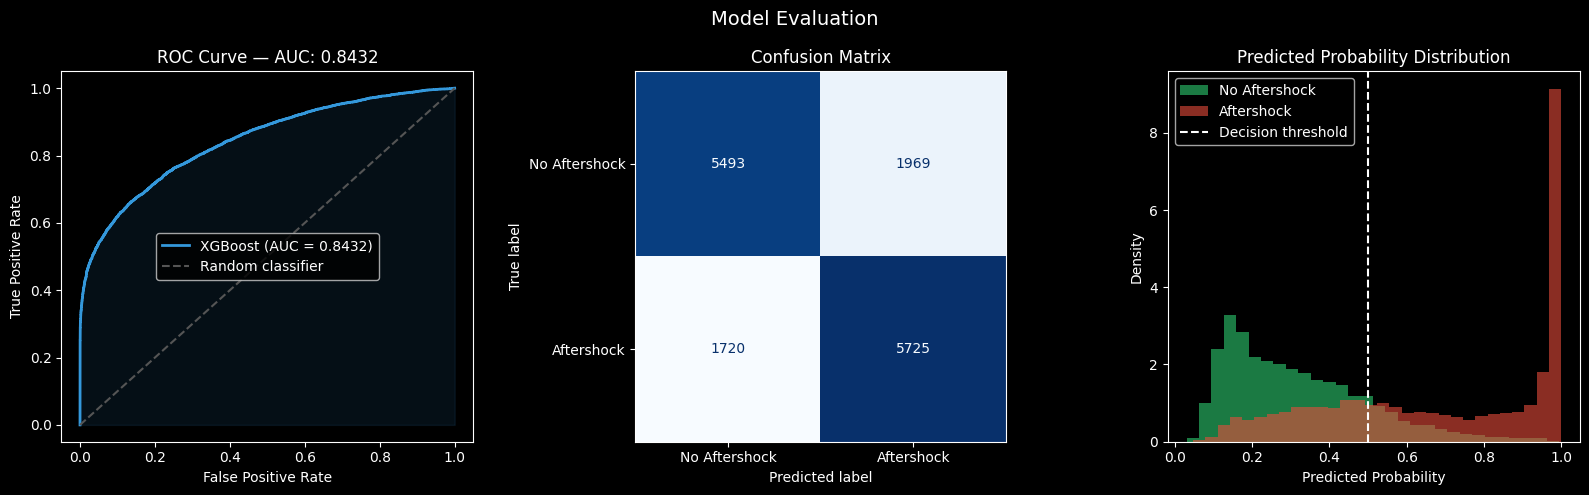

Evaluation plots saved to data/evaluation_plots.png
ROC and confusion matrix data saved for Streamlit


In [26]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Evaluation', fontsize=14)

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'XGBoost (AUC = {auc_score:.4f})')
axes[0].plot([0,1],[0,1], color='#555', linestyle='--', label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve — AUC: {auc_score:.4f}')
axes[0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Aftershock', 'Aftershock'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix')

# 3. Probability distribution by class
axes[2].hist(y_pred_prob[y_test==0], bins=30, alpha=0.6, color='#2ecc71',
             label='No Aftershock', density=True)
axes[2].hist(y_pred_prob[y_test==1], bins=30, alpha=0.6, color='#e74c3c',
             label='Aftershock', density=True)
axes[2].axvline(0.5, color='white', linestyle='--', label='Decision threshold')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Predicted Probability Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig(path + 'data/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved to data/evaluation_plots.png')

# Save ROC curve data for Streamlit
roc_data = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_data.to_csv(path + 'data/roc_curve.csv', index=False)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(path + 'data/confusion_matrix.csv', index=False)
print('ROC and confusion matrix data saved for Streamlit')

## 9. SHAP Explainability

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to each prediction using cooperative game theory. I added this section as the industry standard for ML interpretability.

In [27]:
print('Computing SHAP values (this takes ~1 minute)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global SHAP importance (mean absolute SHAP value per feature)
shap_importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print('\n=== GLOBAL SHAP FEATURE IMPORTANCE ===')
print(shap_importance.to_string(index=False))

# Save SHAP importance for Streamlit
shap_importance.to_csv(path + 'data/shap_importance.csv', index=False)
print('\nSHAP importance saved to data/shap_importance.csv')

Computing SHAP values (this takes ~1 minute)...

=== GLOBAL SHAP FEATURE IMPORTANCE ===
            feature  importance
 seismicity_rate_7d    1.315839
seismicity_rate_30d    0.365308
              depth    0.294048
          magnitude    0.212108
   nearest_fault_km    0.094179
            lat_bin    0.076923
            lon_bin    0.067482
     fault_pressure    0.043653
     depth_category    0.042469
        hour_of_day    0.028925
              month    0.023905
  is_myanmar_region    0.002099
      is_near_fault    0.000074

SHAP importance saved to data/shap_importance.csv


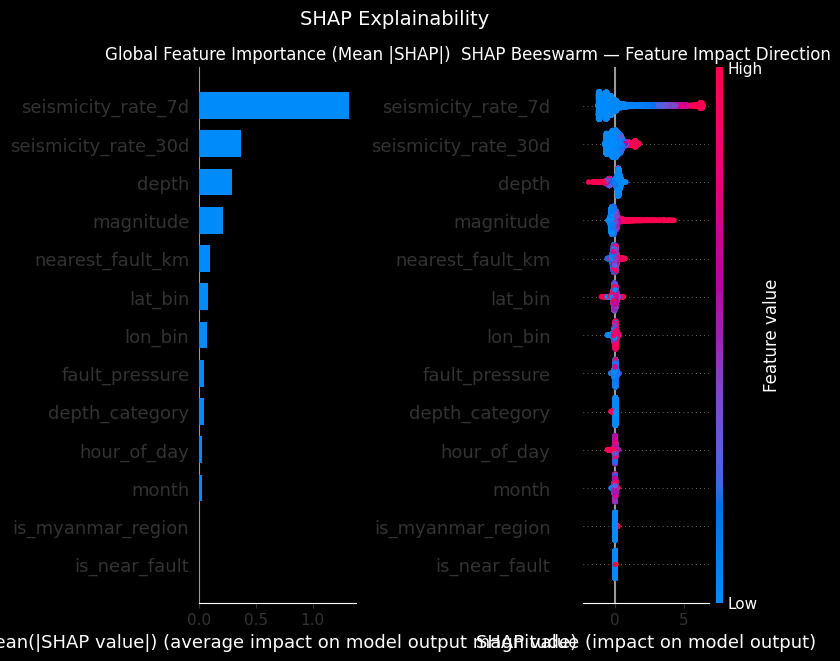

SHAP plots saved to data/shap_plots.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('SHAP Explainability', fontsize=14)

# 1. Summary bar plot (global importance)
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
axes[0].set_title('Global Feature Importance (Mean |SHAP|)')

# 2. Beeswarm plot (shows direction of impact)
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False
)
axes[1].set_title('SHAP Beeswarm — Feature Impact Direction')

plt.tight_layout()
plt.savefig(path + 'data/shap_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plots saved to data/shap_plots.png')

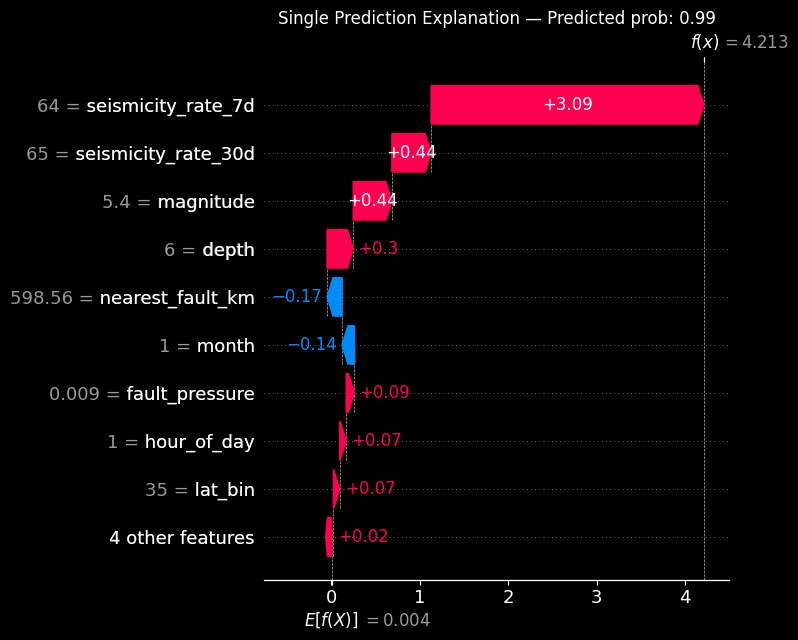

Waterfall plot saved to data/shap_waterfall.png


In [29]:
# Single prediction explanation (waterfall plot)
# Pick a high-probability aftershock prediction to explain
high_prob_idx = np.where(y_pred_prob > 0.7)[0]
if len(high_prob_idx) > 0:
    sample_idx = high_prob_idx[0]
    shap_exp   = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx].values,
        feature_names=FEATURE_COLS
    )
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_exp, show=False)
    plt.title(f'Single Prediction Explanation — Predicted prob: {y_pred_prob[sample_idx]:.2f}')
    plt.tight_layout()
    plt.savefig(path + 'data/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Waterfall plot saved to data/shap_waterfall.png')
else:
    print('No high-probability predictions found — adjust threshold')

## 10. Save Model Artifacts

Save the trained model and supporting artifacts for loading in the Streamlit app.

In [30]:
os.makedirs(path + "models", exist_ok=True)

# ==========================================================
# Save Final Model
# ==========================================================
with open(path + "models/xgb_aftershock_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model (XGB) saved")

# ==========================================================
# Save SHAP Explainer
# ==========================================================
with open(path + "models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("SHAP explainer saved")

# ==========================================================
# Save Feature Order
# ==========================================================
with open(path + "models/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

print("Feature columns saved")

# ==========================================================
# Save Threshold
# ==========================================================
with open(path + "models/best_threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f, indent=2)

print("Threshold saved")

# ==========================================================
# Save Metadata
# ==========================================================
metadata = {
    "model_type": "XGBoostClassifier",
    "training_date": datetime.now().isoformat(),

    "trigger_min_mag": TRIGGER_MIN_MAG,
    "aftershock_min_mag": AFTERSHOCK_MIN_MAG,
    "aftershock_hours": AFTERSHOCK_HOURS,
    "aftershock_radius_km": AFTERSHOCK_RADIUS,

    "n_train_samples": int(len(X_train_bal)),
    "n_test_samples": int(len(X_test)),
    "n_features": int(len(FEATURE_COLS)),

    "feature_cols": FEATURE_COLS,

    "selected_threshold": float(best_threshold),

    "metrics": metrics,

    "cv_auc_mean": float(cv_scores.mean()),
    "cv_auc_std": float(cv_scores.std())
}

with open(path + "models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved")


Model (XGB) saved
SHAP explainer saved
Feature columns saved
Threshold saved
Metadata saved


## 11. Reference
USGS, 2024. Earthquake Hazards Program. https://earthquake.usgs.gov

LANL, 2019. 'LANL-Earthquake-Prediction', Available at: https://www.kaggle.com/competitions/LANL-Earthquake-Prediction (Accessed: 12 April 2026).

Rouet-Leduc, B., Hulbert, C., Lubbers, N., Barros, K., Humphreys, C.J. and Johnson, P.A., 2017. 'Machine Learning Predicts Laboratory Earthquakes', *Geophysical Research Letters*, vol. 44, no. 18, pp.9276–9282, doi: https://doi.org/10.1002/2017gl074677.